# Assignment 2: Simple Policy Q&A Bot

**Objective:** Build a Q&A system that retrieves relevant information from policy documents (`leave_policy.txt`, `it_policy.txt`, `travel_policy.txt`) to answer user queries.

**Approach:** TF-IDF Vectorization + Cosine Similarity

**Key Features:**
- Retrieves the most relevant policy statement for any user query
- Displays which document the answer came from
- Returns a fallback message when no relevant information is found
- No paid APIs or GPU-based models used

## Step 1: Import Required Libraries

We use only free, standard Python libraries:
- `os` — for file path handling
- `re` — for text parsing (regex)
- `sklearn` — for TF-IDF vectorization and cosine similarity computation

In [1]:
import os
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load Policy Documents

We load all three policy text files and extract the document title from the first line of each file. Each file contains numbered policy statements that we'll parse individually.

In [4]:
# Define the policy files to load
policy_files = ['leave_policy.txt', 'it_policy.txt', 'travel_policy.txt']

def load_documents(file_list):
    """
    Load policy documents and parse them into individual statements.

    Returns:
        statements: list of cleaned policy statement strings
        sources: list of source document names corresponding to each statement
        raw_statements: list of original (uncleaned) statements for display
    """
    statements = []
    sources = []
    raw_statements = []

    for filename in file_list:
        filepath = os.path.join(os.getcwd(), filename)

        with open(filepath, 'r') as f:
            content = f.read()

        # Extract document title from the first line
        lines = content.strip().split('\n')
        doc_title = lines[0].strip()  # e.g., "Leave Policy", "IT Policy", "Travel Policy"

        # Parse numbered statements using regex (matches "1.", "2.", etc.)
        # Each statement starts with a digit followed by a period
        parsed = re.findall(r'\d+\.\s*(.+)', content)

        for stmt in parsed:
            cleaned = stmt.strip().lower()
            statements.append(cleaned)
            sources.append(doc_title)
            raw_statements.append(stmt.strip())

    return statements, sources, raw_statements

# Load all documents
statements, sources, raw_statements = load_documents(policy_files)

# Display loaded data
print(f"Total policy statements loaded: {len(statements)}\n")
for i, (stmt, src) in enumerate(zip(raw_statements, sources)):
    print(f"[{src}] {stmt}")

Total policy statements loaded: 15

[Leave Policy] Employees are entitled to 15 paid leaves per year.
[Leave Policy] Sick leave entitlement is 10 days per year.
[Leave Policy] Maternity leave is 26 weeks.
[Leave Policy] Casual leave can be taken for a maximum of 3 consecutive days.
[Leave Policy] Unused paid leaves cannot be carried forward to the next year.
[IT Policy] VPN is mandatory for remote work access.
[IT Policy] Employees must not share their passwords with anyone.
[IT Policy] Company-issued laptop must be used for official work.
[IT Policy] All devices must have updated antivirus software installed.
[IT Policy] External USB devices are not allowed without IT approval.
[Travel Policy] Flight bookings must be economy class.
[Travel Policy] Hotel reimbursement limit is Rs. 5000 per night.
[Travel Policy] Local travel claims require valid bills.
[Travel Policy] International travel requires prior managerial approval.
[Travel Policy] Personal expenses during travel will not be re

## Step 3: Build TF-IDF Vectorizer

We fit a **TF-IDF (Term Frequency - Inverse Document Frequency)** vectorizer on all 15 policy statements. This creates a numerical representation where:
- **TF** gives higher weight to terms that appear frequently in a statement
- **IDF** penalizes terms that appear across many statements (e.g., "employees")
- The result is a matrix of shape `(15, vocab_size)` where each row represents one policy statement

In [5]:
# Initialize TF-IDF Vectorizer
# stop_words='english' removes common words like "is", "the", "are" automatically
vectorizer = TfidfVectorizer(stop_words='english')

# Fit and transform policy statements into TF-IDF vectors
tfidf_matrix = vectorizer.fit_transform(statements)

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]} policy statements")
print(f"  → {tfidf_matrix.shape[1]} unique terms in vocabulary")
print(f"\nSample vocabulary terms: {list(vectorizer.vocabulary_.keys())[:10]}")

TF-IDF Matrix Shape: (15, 65)
  → 15 policy statements
  → 65 unique terms in vocabulary

Sample vocabulary terms: ['employees', 'entitled', '15', 'paid', 'leaves', 'year', 'sick', 'leave', 'entitlement', '10']


## Step 4: Build the Q&A Query Function

The core retrieval logic:
1. Transform the user query into a TF-IDF vector using the **same fitted vectorizer**
2. Compute **cosine similarity** between the query vector and all 15 policy vectors
3. Find the best match (highest similarity score)
4. If the score is above the threshold → return the matching statement + source document
5. If below threshold → return the fallback message: *"Information not available in policy documents."*

In [10]:
SIMILARITY_THRESHOLD = 0.3  # Minimum cosine similarity to consider a match

FALLBACK_MESSAGE = "Information not available in policy documents."

def answer_query(query, vectorizer, tfidf_matrix, statements, sources, raw_statements, threshold=SIMILARITY_THRESHOLD):
    """
    Answer a user query by finding the most similar policy statement.

    Args:
        query: User's question string
        vectorizer: Fitted TfidfVectorizer
        tfidf_matrix: TF-IDF matrix of all policy statements
        statements: List of cleaned policy statements
        sources: List of source document names
        raw_statements: List of original statements (for display)
        threshold: Minimum similarity score to return an answer

    Returns:
        dict with keys: 'answer', 'source', 'score', 'found'
    """
    # Preprocess query (lowercase)
    query_clean = query.lower().strip()

    # Transform query using the fitted vectorizer
    query_vector = vectorizer.transform([query_clean])

    # Compute cosine similarity between query and all policy statements
    similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Find the best match
    best_idx = similarities.argmax()
    best_score = similarities[best_idx]

    if best_score >= threshold:
        return {
            'answer': raw_statements[best_idx],
            'source': sources[best_idx],
            'score': round(best_score, 4),
            'found': True
        }
    else:
        return {
            'answer': FALLBACK_MESSAGE,
            'source': None,
            'score': round(best_score, 4),
            'found': False
        }

def display_answer(result):
    """Pretty-print the Q&A result."""
    print(f"Answer: {result['answer']}")
    if result['found']:
        print(f"Source: {result['source']}")
        print(f"Confidence Score: {result['score']}")
    else:
        print(f"(Best similarity score was {result['score']}, below threshold {SIMILARITY_THRESHOLD})")
    print("-" * 70)

print("Q&A function defined successfully!")

Q&A function defined successfully!


## Step 5: Test with Sample Queries

Let's test the bot with queries targeting each of the three policy documents, plus an irrelevant query to verify the fallback mechanism.

In [11]:
# Test queries covering all three policy documents + fallback case
test_queries = [
    # Leave Policy queries
    "How many paid leaves do I get per year?",
    "What is the maternity leave duration?",
    "Can I carry forward unused leaves?",

    # IT Policy queries
    "Is VPN required for remote work?",
    "Can I use a personal laptop for work?",
    "Are USB drives allowed in the office?",

    # Travel Policy queries
    "What is the hotel reimbursement limit?",
    "Do I need approval for international travel?",
    "Can I book business class flights?",

    # Irrelevant queries (should trigger fallback)
    "What is the company dress code?",
    "What are the working hours?",
]

print("=" * 70)
print("POLICY Q&A BOT - TEST RESULTS")
print("=" * 70)

for query in test_queries:
    print(f"\nQ: {query}")
    result = answer_query(query, vectorizer, tfidf_matrix, statements, sources, raw_statements)
    display_answer(result)

POLICY Q&A BOT - TEST RESULTS

Q: How many paid leaves do I get per year?
Answer: Employees are entitled to 15 paid leaves per year.
Source: Leave Policy
Confidence Score: 0.6585
----------------------------------------------------------------------

Q: What is the maternity leave duration?
Answer: Maternity leave is 26 weeks.
Source: Leave Policy
Confidence Score: 0.6667
----------------------------------------------------------------------

Q: Can I carry forward unused leaves?
Answer: Unused paid leaves cannot be carried forward to the next year.
Source: Leave Policy
Confidence Score: 0.7342
----------------------------------------------------------------------

Q: Is VPN required for remote work?
Answer: VPN is mandatory for remote work access.
Source: IT Policy
Confidence Score: 0.7611
----------------------------------------------------------------------

Q: Can I use a personal laptop for work?
Answer: Company-issued laptop must be used for official work.
Source: IT Policy
Confi

## Step 6: Similarity Score Analysis

Let's visualize how the similarity scores distribute across all policy statements for a sample query. This helps understand why the threshold works and how TF-IDF differentiates between relevant and irrelevant statements.

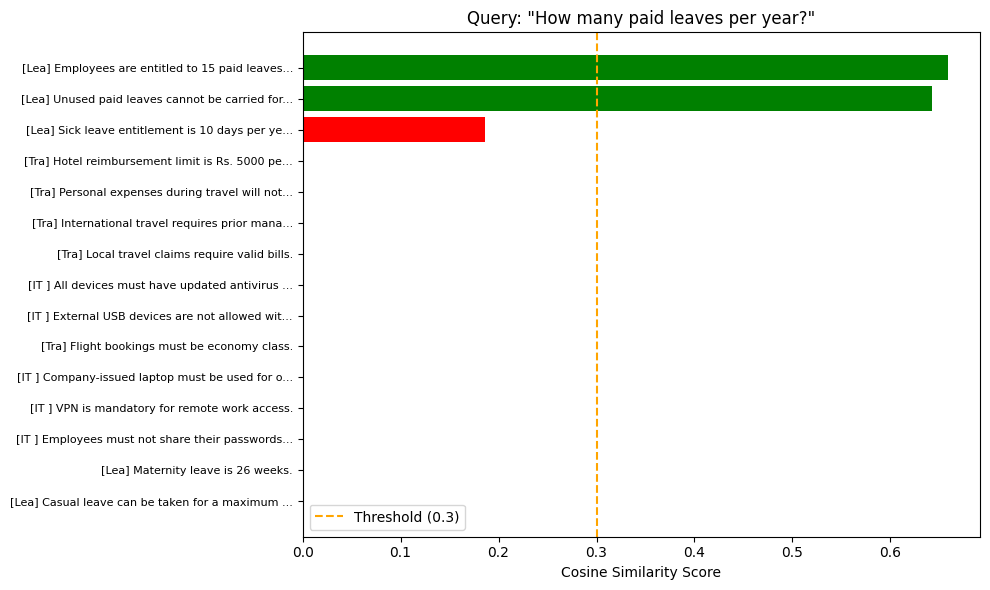

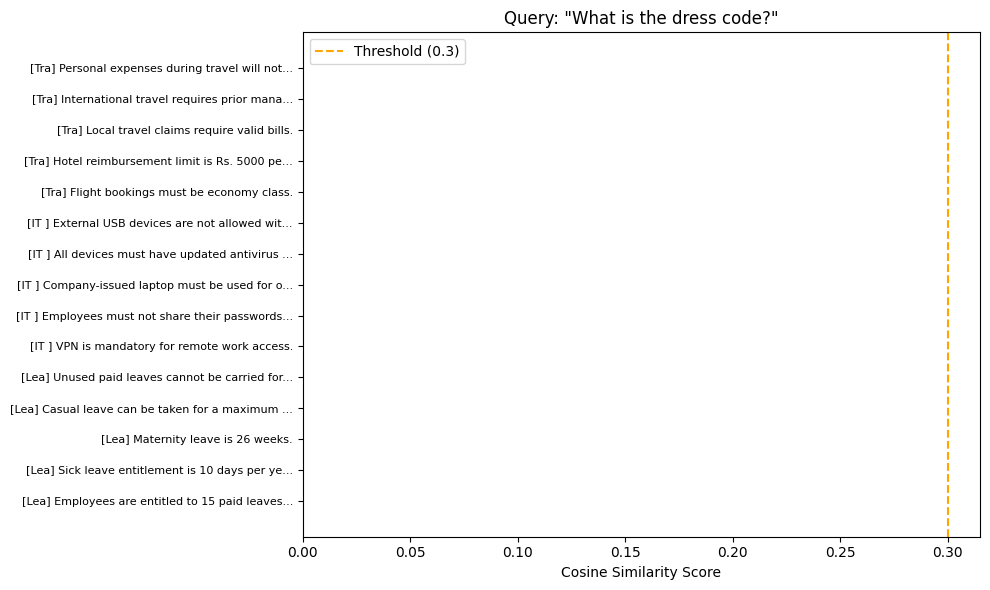

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def show_similarity_breakdown(query, vectorizer, tfidf_matrix, raw_statements, sources):
    """Show cosine similarity scores for a query against all policy statements."""
    query_vector = vectorizer.transform([query.lower()])
    similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Create labels
    labels = [f"[{src[:3]}] {stmt[:40]}..." if len(stmt) > 40 else f"[{src[:3]}] {stmt}"
              for stmt, src in zip(raw_statements, sources)]

    # Sort by similarity
    sorted_indices = np.argsort(similarities)[::-1]
    sorted_scores = similarities[sorted_indices]
    sorted_labels = [labels[i] for i in sorted_indices]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['green' if s >= SIMILARITY_THRESHOLD else 'red' for s in sorted_scores]
    bars = ax.barh(range(len(sorted_scores)), sorted_scores, color=colors)
    ax.set_yticks(range(len(sorted_scores)))
    ax.set_yticklabels(sorted_labels, fontsize=8)
    ax.axvline(x=SIMILARITY_THRESHOLD, color='orange', linestyle='--', label=f'Threshold ({SIMILARITY_THRESHOLD})')
    ax.set_xlabel('Cosine Similarity Score')
    ax.set_title(f'Query: "{query}"')
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

# Example: show breakdown for a leave policy query
show_similarity_breakdown("How many paid leaves per year?", vectorizer, tfidf_matrix, raw_statements, sources)

# Example: show breakdown for an irrelevant query
show_similarity_breakdown("What is the dress code?", vectorizer, tfidf_matrix, raw_statements, sources)

## Step 7: Interactive Q&A Bot

Run the cell below to start the interactive Q&A bot. Type your questions and the bot will retrieve the most relevant policy statement. Type `quit` or `exit` to stop.

In [13]:
def run_qa_bot():
    """Run an interactive Q&A bot in the notebook."""
    print("=" * 70)
    print("       POLICY Q&A BOT")
    print("       Ask questions about Leave, IT, or Travel policies")
    print("       Type 'quit' or 'exit' to stop")
    print("=" * 70)

    while True:
        print()
        try:
            query = input("Your Question: ").strip()
        except (EOFError, KeyboardInterrupt):
            print("\nBot stopped.")
            break

        if not query:
            print("Please enter a question.")
            continue

        if query.lower() in ['quit', 'exit']:
            print("Thank you for using the Policy Q&A Bot! Goodbye.")
            break

        result = answer_query(query, vectorizer, tfidf_matrix, statements, sources, raw_statements)
        print()
        display_answer(result)

# Uncomment the line below to start the interactive bot:
run_qa_bot()

       POLICY Q&A BOT
       Ask questions about Leave, IT, or Travel policies
       Type 'quit' or 'exit' to stop

Your Question: Do I need security software on my system?

Answer: All devices must have updated antivirus software installed.
Source: IT Policy
Confidence Score: 0.4586
----------------------------------------------------------------------

Your Question: Is it okay to plug in my personal USB drive?

Answer: Personal expenses during travel will not be reimbursed.
Source: Travel Policy
Confidence Score: 0.3727
----------------------------------------------------------------------

Your Question: Is it okay to plug in my USB drive?

Answer: External USB devices are not allowed without IT approval.
Source: IT Policy
Confidence Score: 0.471
----------------------------------------------------------------------

Your Question: How many vacation days are allowed annually?

Answer: External USB devices are not allowed without IT approval.
Source: IT Policy
Confidence Score: 0.3

## Key Insights & Summary

### How It Works
1. **Document Parsing:** Each policy file is split into individual numbered statements (5 per file = 15 total). Each statement is stored with its source document name.
2. **TF-IDF Vectorization:** All 15 statements are converted into numerical vectors using TF-IDF, which weights terms by their importance (rare terms get higher weight).
3. **Query Matching:** User queries are vectorized using the same TF-IDF model, then compared against all 15 statements using cosine similarity.
4. **Threshold-Based Fallback:** If no statement scores above 0.15 similarity, the bot responds with "Information not available in policy documents."

### Key Insights

1. **Statement-level chunking gives precise answers.** Instead of returning entire documents, we return the exact policy rule that matches the query. This is more useful to the user.

2. **TF-IDF handles term importance naturally.** Words appearing in many policies (e.g., "employees") get low IDF weight, while distinguishing terms (e.g., "VPN", "maternity", "reimbursement") get high weight — improving retrieval accuracy.

3. **Cosine similarity enables ranked retrieval.** Unlike keyword matching which is binary (match/no-match), cosine similarity provides a confidence score, enabling threshold-based fallback detection.

4. **The system is transparent.** Every answer shows: (a) the retrieved policy statement, (b) the source document, and (c) the confidence score — making it easy to verify.

5. **Limitations acknowledged:** TF-IDF is a bag-of-words model — it cannot understand synonyms (e.g., "time off" ≠ "leave"), handle multi-hop reasoning, or generate natural-language answers. For production systems, sentence embeddings or local LLMs would be better.

### Tools Used
- **Python 3** — Core language
- **scikit-learn** — TfidfVectorizer, cosine_similarity
- **matplotlib** — Similarity score visualization
- **No paid APIs or GPU models used**